Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 47s 61ms/step - accuracy: 0.9367 - loss: 0.2113 - val_accuracy: 0.9770 - val_loss: 0.0768
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.9811 - loss: 0.0620 - val_accuracy: 0.9833 - val_loss: 0.0577
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 61ms/step - accuracy: 0.9864 - loss: 0.0432 - val_accuracy: 0.9873 - val_loss: 0.0444
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.9898 - loss: 0.0321 - val_accuracy: 0.9880 - val_loss: 0.0428
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 59ms/step - accuracy: 0.9917 - loss: 0.0256 - val_accuracy: 0.9878 - val_loss: 0.0420
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9896 - loss: 0.0319
Test Accuracy: 0.9896000027656555

Actual digit: 7


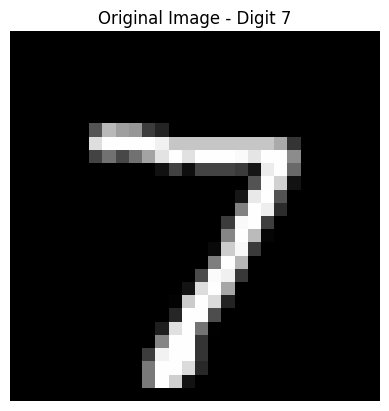


Original image shape:
(28, 28, 1)

Convolution output shape:
(1, 13, 13, 32)

Pooling output shape:
(1, 11, 11, 64)


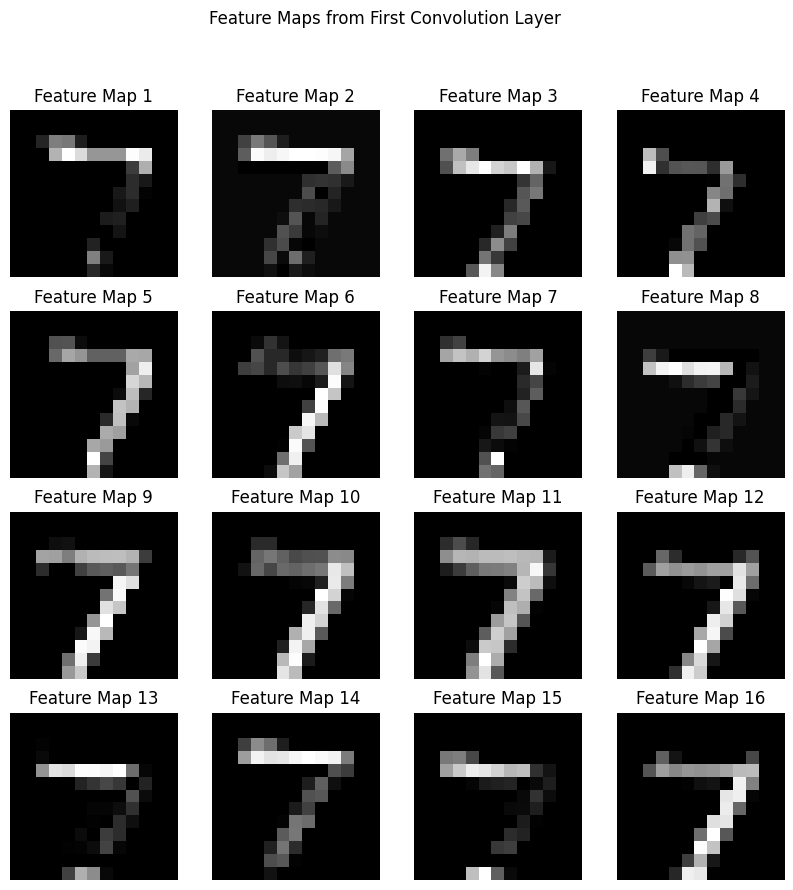

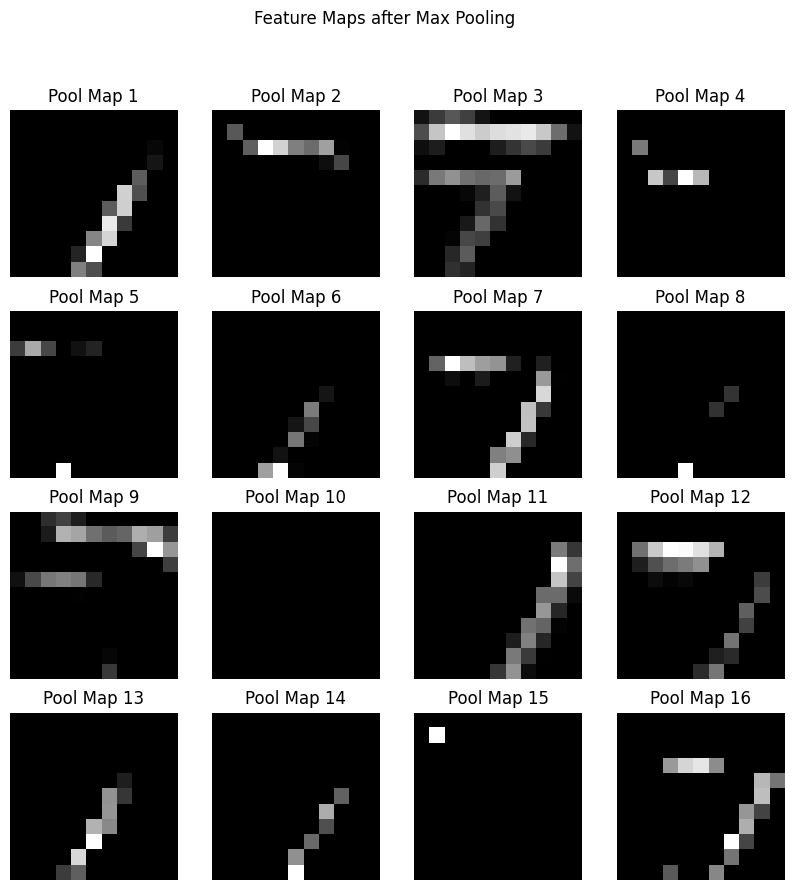

Name: Omkar Vaidya
Roll No.: 40


In [5]:
!pip install tensorflow
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense


# Load MNIST dataset, which will return 2 column values
# MNIST contains images of handwritten digits 0 through 9.
# There are: 60,000 training images, 10,000 testing images
# Each image is 28 × 28 pixels (width and height), 28 × 28 = 784 pixels
# input_shape=(28, 28, 1) 1 indicates black and white
# Each pixel has a value representing its brightness. 0 → black, 255 → white

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)#Training images: (60000, 28, 28)
print("Testing images:", x_test.shape)#Testing images: (10000, 28, 28)

# Reshape images as per CNN requirements
# The -1 tells NumPy to automatically calculate the number of images.
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


# Normalizaton to bring any value from 0 to 255 to the value between 0 to 1.
x_train = x_train / 255.0
x_test = x_test / 255.0

from tensorflow.keras.layers import Input
# Build CNN
model = Sequential()
# 32 filters, Each filter is a 3 × 3 matrix.
model.add(Input(shape=(28, 28, 1)))
model.add(Conv2D(32,(3, 3),activation="relu"))
# A 2 × 2 window looks at four values and keeps the largest one.
model.add(MaxPooling2D((2, 2)))
# The 2nd convolution combines those simpler features into more complex patterns.
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
# Fully connected layer
model.add(Dense(64, activation="relu"))
# Output layer → 10 possible digits
model.add(Dense(10, activation="softmax" ))

# Compile
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train the model for actual learning
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2 )
# Evaluate
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

# Select one test image to find feature map
image = x_test[0]
print("\nActual digit:", y_test[0])
plt.imshow(image.reshape(28, 28), cmap="gray") # restores the original grid structure from flattened
plt.title("Original Image - Digit " + str(y_test[0]))
plt.axis("off")
plt.show()

# CREATE FEATURE MAP MODEL
feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[
        model.layers[1].output,
        model.layers[2].output
    ]
)
# GET FEATURE MAPS
image_input = np.expand_dims(image, axis=0)
outputs = feature_model.predict(image_input,verbose=0)

# Output of first convolution
conv_output = outputs[0]
# Output after first pooling
pool_output = outputs[1]

print("\nOriginal image shape:")
print(image.shape)
print("\nConvolution output shape:")
print(conv_output.shape)
print("\nPooling output shape:")
print(pool_output.shape)

# DISPLAY CONVOLUTION FEATURE MAPS
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(conv_output[0, :, :, i], cmap="gray")
    plt.title("Feature Map " + str(i + 1))
    plt.axis("off")
plt.suptitle("Feature Maps from First Convolution Layer")
plt.show()

# DISPLAY POOLING FEATURE MAPS
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(pool_output[0, :, :, i], cmap="gray")
    plt.title("Pool Map " + str(i + 1))
    plt.axis("off")
plt.suptitle("Feature Maps after Max Pooling")
plt.show()

print("Name: Omkar Vaidya")
print("Roll No.: 40")